In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!unzip -q "/content/drive/MyDrive/datasets.zip" -d "/content/"

✅ Data Ready!
Train: 36882 | Val: 4098 | Test: 10246

Train Set Class Distribution:
Angry     : 4230 samples
Disgust   : 1038 samples
Fear      : 3940 samples
Happy     : 10788 samples
Sad       : 6740 samples
Surprise  : 6131 samples
Neutral   : 4015 samples


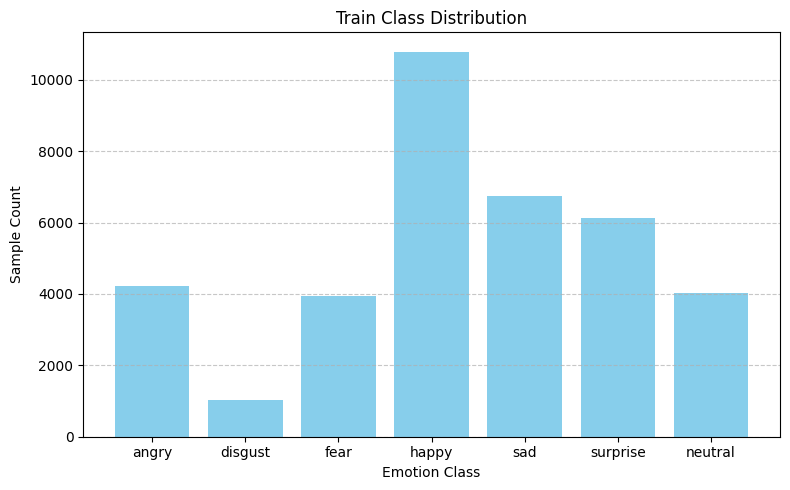


Validation Set Class Distribution:
Angry     : 470 samples
Disgust   : 115 samples
Fear      : 438 samples
Happy     : 1199 samples
Sad       : 749 samples
Surprise  : 681 samples
Neutral   : 446 samples


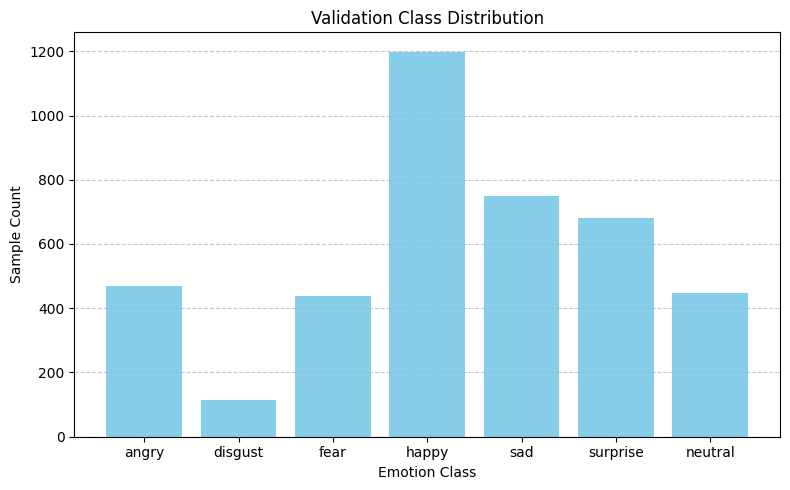


Test Set Class Distribution:
Angry     : 1120 samples
Disgust   : 271 samples
Fear      : 1098 samples
Happy     : 2959 samples
Sad       : 1913 samples
Surprise  : 1725 samples
Neutral   : 1160 samples


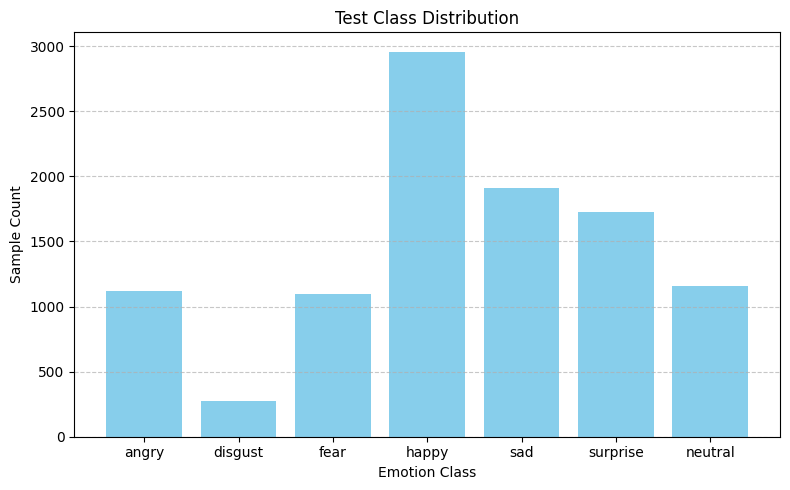

In [ ]:
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader, Subset, ConcatDataset
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np
import os
from collections import Counter

# Dataset paths
fer_train_path = '/content/datasets/fer/train'
fer_test_path  = '/content/datasets/fer/test'
raf_train_path = '/content/datasets/rafdb/train'
raf_test_path  = '/content/datasets/rafdb/test'

# Transform
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomHorizontalFlip(p=0.3),  # Flip with 30% chance
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.RandomRotation(degrees=(-10, +10)),
    transforms.Resize((48, 48)), # Optional but safe
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# Load train datasets separately
fer_train = ImageFolder(root=fer_train_path, transform=transform)
raf_train = ImageFolder(root=raf_train_path, transform=transform)

# Combine FER + RAF train sets
combined_train_dataset = ConcatDataset([fer_train, raf_train])

# Collect all labels from combined_train_dataset for stratification
all_labels = np.array([fer_train[i][1] for i in range(len(fer_train))] +
                      [raf_train[i][1] for i in range(len(raf_train))])

# Stratified split into train (85%) and val (15%)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
for train_idx, val_idx in sss.split(np.zeros(len(all_labels)), all_labels):
    train_data = Subset(combined_train_dataset, train_idx)
    val_data   = Subset(combined_train_dataset, val_idx)

# Load test datasets (no split needed)
fer_test = ImageFolder(root=fer_test_path, transform=transform)
raf_test = ImageFolder(root=raf_test_path, transform=transform)
combined_test_dataset = ConcatDataset([fer_test, raf_test])

# Dataloaders
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader  = DataLoader(combined_test_dataset, batch_size=64, shuffle=False)

# Print summary
print(f"✅ Data Ready!")
print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(combined_test_dataset)}")

class_names = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']

def count_class_distribution(dataset, name, class_names):
    labels = [dataset[i][1] for i in range(len(dataset))]
    counter = Counter(labels)

    print(f"\n{name} Set Class Distribution:")
    for class_idx in sorted(counter):
        class_name = class_names[class_idx] if class_idx < len(class_names) else f"Class {class_idx}"
        print(f"{class_name.capitalize():<10}: {counter[class_idx]} samples")

    # Plot as bar chart
    counts = [counter[i] if i in counter else 0 for i in range(len(class_names))]
    plt.figure(figsize=(8, 5))
    plt.bar(class_names, counts, color='skyblue')
    plt.title(f"{name} Class Distribution")
    plt.xlabel("Emotion Class")
    plt.ylabel("Sample Count")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

count_class_distribution(train_data, "Train", class_names)
count_class_distribution(val_data, "Validation", class_names)
count_class_distribution(combined_test_dataset, "Test", class_names)

In [ ]:
# class CBAM(nn.Module):
#     def __init__(self, channels, reduction=16, kernel_size=7):
#         super(CBAM, self).__init__()
#         self.channel_att = nn.Sequential(
#             nn.AdaptiveAvgPool2d(1),
#             nn.Conv2d(channels, channels // reduction, 1),
#             nn.ReLU(),
#             nn.Conv2d(channels // reduction, channels, 1),
#             nn.Sigmoid()
#         )
#         self.spatial_att = nn.Sequential(
#             nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2),
#             nn.Sigmoid()
#         )

#     def forward(self, x):
#         ca = self.channel_att(x)
#         x = x * ca

#         avg_out = torch.mean(x, dim=1, keepdim=True)
#         max_out, _ = torch.max(x, dim=1, keepdim=True)
#         sa = self.spatial_att(torch.cat([avg_out, max_out], dim=1))

#         return x * sa

class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, kernel_size=5):
        super(CBAM, self).__init__()

        # Channel Attention (using both avg and max pool)
        self.channel_mlp = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1),
            nn.ReLU(),
            nn.Conv2d(channels // reduction, channels, 1)
        )

        # Spatial Attention
        self.spatial = nn.Sequential(
            nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size // 2),
            nn.Sigmoid()
        )

    def forward(self, x):
        # Channel Attention
        avg_pool = F.adaptive_avg_pool2d(x, 1)
        max_pool = F.adaptive_max_pool2d(x, 1)
        ca = self.channel_mlp(avg_pool) + self.channel_mlp(max_pool)
        ca = torch.sigmoid(ca)
        x = x * ca

        # Spatial Attention
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        sa = self.spatial(torch.cat([avg_out, max_out], dim=1))

        return x * sa

In [ ]:
class ResidualMaskBlock(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, in_channels, 3, padding=1)
        self.bn = nn.BatchNorm2d(in_channels)
        self.relu = nn.ReLU()
        self.mask = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        residual = x
        out = self.relu(self.bn(self.conv(x)))
        out = out * self.mask(out)
        return out + residual

In [ ]:
class EmotionNet(nn.Module):
    def __init__(self, dropout_rate=0.4):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            ResidualMaskBlock(64),
            CBAM(64),
            nn.MaxPool2d(2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            ResidualMaskBlock(128),
            CBAM(128),
            nn.MaxPool2d(2)
        )
        self.layer3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            ResidualMaskBlock(256),
            CBAM(256),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_rate),
            nn.Linear(256 * 6 * 6, 7)  # 7 classes
        )

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        return self.fc(x)

In [ ]:
# Only CNN model
import torch
import torch.nn as nn

class EmotionNet(nn.Module):
    def __init__(self, dropout_rate=0.4):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.layer3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_rate),
            nn.Linear(256 * 6 * 6, 7)  # 7 classes
        )

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        return self.fc(x)

In [ ]:
# CNN + RMN model
import torch
import torch.nn as nn

# Assuming ResidualMaskBlock is already defined somewhere

class EmotionNet(nn.Module):
    def __init__(self, dropout_rate=0.4):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            ResidualMaskBlock(64),
            nn.MaxPool2d(2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            ResidualMaskBlock(128),
            nn.MaxPool2d(2)
        )
        self.layer3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            ResidualMaskBlock(256),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_rate),
            nn.Linear(256 * 6 * 6, 7)  # 7 output classes
        )

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        return self.fc(x)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Replace with your model definition
model = EmotionNet().to(device)  # Ensure EmotionNet is defined beforehand

# Define loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-5)

# Class names for display
class_names = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']

# ✅ Evaluation function
def evaluate(model, loader, return_loss=False):
    model.eval()
    preds, targets = [], []
    total_loss = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            out = model(images)
            loss = criterion(out, labels)
            total_loss += loss.item()
            pred = out.argmax(dim=1)
            preds.extend(pred.cpu().numpy())
            targets.extend(labels.cpu().numpy())
    acc = accuracy_score(targets, preds)
    if return_loss:
        return acc, total_loss
    else:
        print(f"Accuracy: {acc * 100:.2f}%")
        return acc

# ✅ Confusion Matrix function
def plot_confusion_matrix(model, loader, class_names=None):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues', xticks_rotation=45)
    plt.title("Confusion Matrix on Test Set")
    plt.show()

def train(model, train_loader, val_loader, epochs):
    # Define scheduler
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(images)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            preds = out.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        # Step the scheduler
        scheduler.step()

        train_acc = correct / total * 100
        print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {total_loss:.4f} | Train Acc: {train_acc:.2f}%")

        # Evaluate on validation set every 5th epoch
        if (epoch + 1) % 5 == 0:
            val_acc, val_loss = evaluate(model, val_loader, return_loss=True)
            print(f"               └── Val Loss: {val_loss:.4f} | Val Acc: {val_acc * 100:.2f}%")

    # Final validation evaluation after training finishes
    print("\nFinal Validation Evaluation:")
    val_acc, val_loss = evaluate(model, val_loader, return_loss=True)
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc * 100:.2f}%")

Epoch [1/30] - Train Loss: 802.1417 | Train Acc: 47.24%
Epoch [2/30] - Train Loss: 655.4090 | Train Acc: 57.65%
Epoch [3/30] - Train Loss: 603.9224 | Train Acc: 60.99%
Epoch [4/30] - Train Loss: 570.3793 | Train Acc: 63.43%
Epoch [5/30] - Train Loss: 543.0819 | Train Acc: 64.94%
               └── Val Loss: 63.9319 | Val Acc: 63.37%
Epoch [6/30] - Train Loss: 523.5216 | Train Acc: 66.43%
Epoch [7/30] - Train Loss: 506.2649 | Train Acc: 67.37%
Epoch [8/30] - Train Loss: 492.4969 | Train Acc: 68.61%
Epoch [9/30] - Train Loss: 475.6717 | Train Acc: 69.30%
Epoch [10/30] - Train Loss: 459.7193 | Train Acc: 70.58%
               └── Val Loss: 59.5001 | Val Acc: 66.01%
Epoch [11/30] - Train Loss: 423.3935 | Train Acc: 73.00%
Epoch [12/30] - Train Loss: 408.3846 | Train Acc: 73.79%
Epoch [13/30] - Train Loss: 396.0143 | Train Acc: 74.77%
Epoch [14/30] - Train Loss: 387.4353 | Train Acc: 75.52%
Epoch [15/30] - Train Loss: 375.3553 | Train Acc: 76.04%
               └── Val Loss: 59.3867 | Val A

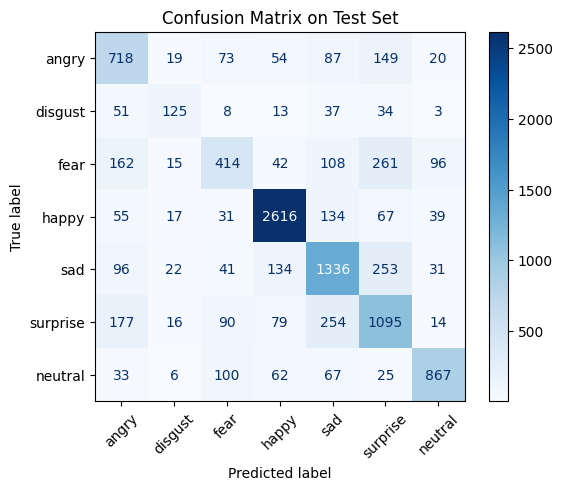


📋 Classification Report:
              precision    recall  f1-score   support

       angry     0.5666    0.6455    0.6035      1120
     disgust     0.6049    0.4576    0.5210       271
        fear     0.5485    0.3862    0.4532      1098
       happy     0.8831    0.8831    0.8831      2959
         sad     0.6445    0.6926    0.6677      1913
    surprise     0.5671    0.6220    0.5933      1725
     neutral     0.8111    0.7586    0.7840      1160

    accuracy                         0.6990     10246
   macro avg     0.6608    0.6351    0.6437     10246
weighted avg     0.6994    0.6990    0.6967     10246


📈 Macro F1 Score on Test Set: 0.6511


In [ ]:
# ✅ Train the model
train(model, train_loader, val_loader, epochs=30)

print("\n🔍 Final Test Accuracy:")
evaluate(model, test_loader)

print("\n📊 Confusion Matrix:")
plot_confusion_matrix(model, test_loader, class_names=class_names)

# ✅ Classification Report (Precision, Recall, F1 for each class)
from sklearn.metrics import classification_report

def print_classification_metrics(model, loader, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print("\n📋 Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

# Call classification report
print_classification_metrics(model, test_loader, class_names=class_names)

# ✅ Macro F1 Score
from sklearn.metrics import f1_score

def print_macro_f1(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    print(f"\n📈 Macro F1 Score on Test Set: {macro_f1:.4f}")

# Call macro F1 score
print_macro_f1(model, test_loader)

In [ ]:
# # ✅ Training function
# def train(model, train_loader, val_loader, epochs):
#     for epoch in range(epochs):
#         model.train()
#         total_loss = 0
#         correct = 0
#         total = 0

#         for images, labels in train_loader:
#             images, labels = images.to(device), labels.to(device)
#             optimizer.zero_grad()
#             out = model(images)
#             loss = criterion(out, labels)
#             loss.backward()
#             optimizer.step()

#             total_loss += loss.item()
#             preds = out.argmax(dim=1)
#             correct += (preds == labels).sum().item()
#             total += labels.size(0)

#         train_acc = correct / total * 100
#         print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {total_loss:.4f} | Train Acc: {train_acc:.2f}%")

#         # val_acc, val_loss = evaluate(model, val_loader, return_loss=True)
#         # print(f"               └── Val Loss: {val_loss:.4f} | Val Acc: {val_acc * 100:.2f}%")